# Vibrações Forçadas

Já entendemos as vibrações livres (todos os regimes, ditados pelo discriminante) e já sabemos resolver equações não homogêneas com o método dos coeficientes a determinar. Chegou a hora de juntar tudo: vamos forçar o oscilador com a força harmônica mais natural que existe,

$$
F(t) = F_0\cos(\omega t),
$$

e ver o que acontece. Vamos em duas partes: primeiro **com** amortecimento, depois **sem**.

## Parte 1: vibração amortecida forçada

$$
mx'' + \gamma x' + kx = F_0\cos(\omega t), \qquad m,\gamma,k>0.
$$

Vamos resolver um exemplo com números concretos, prestando atenção em dois fatos que — já adianto — vão se revelar completamente gerais.

### Um exemplo com contas

Resolva

$$
x''+2x'+5x=3\cos t, \qquad x(0)=0,\ x'(0)=0.
$$

**Homogênea associada:** $r^2+2r+5=0 \Rightarrow r=-1\pm2i$, então $x_h=e^{-t}(c_1\cos2t+c_2\,\text{sen}\,2t)$ — subamortecida.

**Solução particular:** tentativa $x_p=A\cos t+B\,\text{sen}\,t$ (sem risco de ressonância, já que $\omega=1\neq\mu=2$). Substituindo e agrupando:

$$
4A+2B=3, \qquad 4B-2A=0 \quad\Longrightarrow\quad A=\frac{3}{5},\ B=\frac{3}{10}.
$$

**Solução geral:** $x(t)=e^{-t}(c_1\cos2t+c_2\,\text{sen}\,2t) + \dfrac35\cos t+\dfrac{3}{10}\,\text{sen}\,t$. Usando as condições iniciais (contas de sempre): $c_1=-\tfrac35$, $c_2=-\tfrac{9}{20}$.

Resíduo: 0
x(0)  = 0
x'(0) = 0


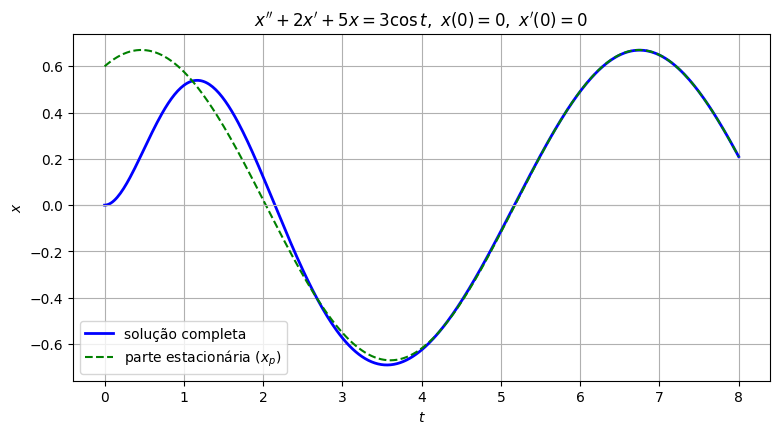

In [14]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

t = sp.symbols('t', real=True)
c1, c2 = sp.Rational(-3, 5), sp.Rational(-9, 20)

x = sp.exp(-t)*(c1*sp.cos(2*t) + c2*sp.sin(2*t)) + sp.Rational(3, 5)*sp.cos(t) + sp.Rational(3, 10)*sp.sin(t)

print("Resíduo:", sp.simplify(sp.diff(x, t, 2) + 2*sp.diff(x, t) + 5*x - 3*sp.cos(t)))
print("x(0)  =", x.subs(t, 0))
print("x'(0) =", sp.diff(x, t).subs(t, 0))

t_vals = np.linspace(0, 8, 400)
x_vals = np.exp(-t_vals)*(-0.6*np.cos(2*t_vals) - 0.45*np.sin(2*t_vals)) + 0.6*np.cos(t_vals) + 0.3*np.sin(t_vals)
x_estacionaria = 0.6*np.cos(t_vals) + 0.3*np.sin(t_vals)

plt.figure(figsize=(9, 4.5))
plt.plot(t_vals, x_vals, 'b', linewidth=2, label='solução completa')
plt.plot(t_vals, x_estacionaria, 'g--', linewidth=1.5, label='parte estacionária ($x_p$)')
plt.axhline(0, color='0.7', linewidth=0.8)
plt.title(r"$x''+2x'+5x=3\cos t,\ x(0)=0,\ x'(0)=0$")
plt.xlabel("$t$"); plt.ylabel("$x$")
plt.legend()
plt.grid(True)
plt.show()

Repare em dois fatos, bem visíveis no gráfico:

1. A parte da homogênea, $e^{-t}(\ldots)$, **desaparece** conforme $t$ cresce — depois de pouco tempo, a solução completa gruda na curva verde tracejada.
2. Essa curva verde, a solução particular, é uma **onda pura na frequência da força** ($\omega=1$, não a frequência natural $\mu=2$!) — um cosseno defasado.

Chamamos $x_p$ de **solução estacionária** (ou de regime permanente): é o que sobra depois de 'esquecido' o passado, e depende só da força aplicada, não da condição inicial.

Chamamos $x_h$ de **solução transiente**: carrega a 'memória' da condição inicial e da natureza intrínseca do sistema (a equação homogênea), mas se dissipa com o tempo.

Isso não foi coincidência dos números escolhidos. Para **quaisquer** $m,\gamma,k>0$ (e qualquer um dos três casos do discriminante, sub, crítico ou superamortecido), o mesmo padrão se repete:

* $x_h\to0$ quando $t\to\infty$, porque a parte real de toda raiz é $-\gamma/(2m)<0$ sempre que $\gamma>0$ (confira nas três fórmulas gerais da aula de vibrações livres).
* $x_p$ é sempre uma onda pura na frequência de forçamento $\omega$, com amplitude e fase que dependem de $m,\gamma,k,\omega$:

$$
x_p(t) = R(\omega)\cos\big(\omega t-\delta(\omega)\big),
$$

$$
\qquad R(\omega)=\frac{F_0}{\sqrt{(k-m\omega^2)^2+(\gamma\omega)^2}}, \qquad \tan\delta(\omega)=\frac{\gamma\omega}{k-m\omega^2}.
$$

## Parte 2: vibração não amortecida forçada — batimento e ressonância

Agora tiramos o amortecimento ($\gamma=0$): a homogênea deixa de morrer, e a interação entre a frequência natural $\omega_0=\sqrt{k/m}$ e a frequência de forçamento $\omega$ vira o centro das atenções.

$$
mx''+kx=F_0\cos(\omega t), \qquad x(0)=0,\ x'(0)=0.
$$

Usando a fórmula geral da Parte 1 com $\gamma=0$ temos:

$$x_p=\dfrac{F_0}{k-m\omega^2}\cos\omega t = \dfrac{F_0}{m(\omega_0^2-\omega^2)}\cos\omega t$$

(supondo $\omega\neq\omega_0$). A homogênea é $x_h=c_1\cos\omega_0t+c_2\,\text{sen}\,\omega_0t$.

Aplicando as condições iniciais $x(0)=x'(0)=0$ (contas de sempre): $c_1=-\dfrac{F_0}{m(\omega_0^2-\omega^2)}$, $c_2=0$.

Logo,

$$
x(t) = \frac{F_0}{m(\omega_0^2-\omega^2)}\Big[\cos(\omega t)-\cos(\omega_0t)\Big].
$$

Usando a identidade trigonométrica $\cos A-\cos B=-2\,\text{sen}\!\left(\frac{A+B}{2}\right)\text{sen}\!\left(\frac{A-B}{2}\right)$:

$$
x(t) = \frac{2F_0}{m(\omega_0^2-\omega^2)}\,\text{sen}\!\left(\frac{\omega_0-\omega}{2}t\right)\text{sen}\!\left(\frac{\omega_0+\omega}{2}t\right).
$$

Quando $\omega$ está **perto** de $\omega_0$:

* O segundo fator, $\text{sen}\big(\frac{\omega_0+\omega}{2}t\big)$, oscila rápido (frequência próxima de $\omega_0$), é a 'portadora'.

* O primeiro fator, $\text{sen}\big(\frac{\omega_0-\omega}{2}t\big)$, oscila devagar (frequência pequena, já que $\omega_0-\omega\approx0$), é o **envelope**, que modula lentamente a amplitude da portadora.

Esse é o fenômeno do **batimento**.

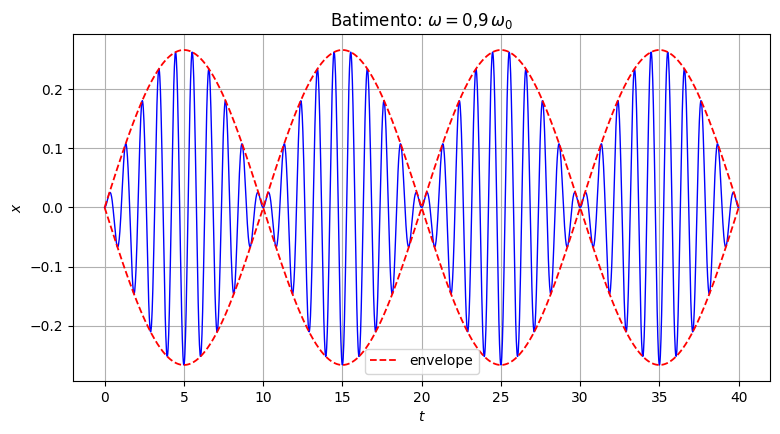

In [20]:
w0_s, w_s, m_s, F0_s, t_s = sp.symbols('omega_0 omega m F_0 t', positive=True)

x_bat = F0_s/(m_s*(w0_s**2 - w_s**2)) * (sp.cos(w_s*t_s) - sp.cos(w0_s*t_s))

m_, k_ = 1.0, (2*np.pi)**2
w0 = np.sqrt(k_/m_)
w_bat = 0.9*w0
F0 = 1.0

t_vals = np.linspace(0, 40, 2000)
x_vals = F0/(m_*(w0**2 - w_bat**2)) * (np.cos(w_bat*t_vals) - np.cos(w0*t_vals))
envelope = np.abs(2*F0/(m_*(w0**2 - w_bat**2)) * np.sin((w0 - w_bat)*t_vals/2))

plt.figure(figsize=(9, 4.5))
plt.plot(t_vals, x_vals, 'b', linewidth=1)
plt.plot(t_vals, envelope, 'r--', linewidth=1.3, label='envelope')
plt.plot(t_vals, -envelope, 'r--', linewidth=1.3)
plt.title(r"Batimento: $\omega=0{,}9\,\omega_0$")
plt.xlabel(r"$t$"); plt.ylabel(r"$x$")
plt.legend()
plt.grid(True)
plt.show()

### O limite de ressonância, via L'Hôpital

O que acontece com essa fórmula quando $\omega\to\omega_0$, ou seja, quando a força é aplicada exatamente na frequência natural? Olhando para

$$
x(t) = \frac{F_0}{m}\cdot\frac{\cos(\omega t)-\cos(\omega_0t)}{\omega_0^2-\omega^2},
$$

conforme $\omega\to\omega_0$, tanto o numerador quanto o denominador tendem a $0$, levando a uma indeterminação $0/0$.

Assim, podemos aplicar a regra de L'Hôpital (derivando em relação a $\omega$, com $t$ fixo):

$$
\lim_{\omega\to\omega_0}\frac{\cos(\omega t)-\cos(\omega_0t)}{\omega_0^2-\omega^2} = \lim_{\omega\to\omega_0}\frac{-t\,\text{sen}(\omega t)}{-2\omega} = \frac{t\,\text{sen}(\omega_0t)}{2\omega_0}.
$$

Logo,

$$
x(t) \ \longrightarrow\ \frac{F_0}{2m\omega_0}\,t\,\text{sen}(\omega_0t) \qquad \text{quando } \omega\to\omega_0.
$$

Repare: é exatamente a forma $t\,\text{sen}(\omega_0t)$ que já tínhamos encontrado pelo método dos coeficientes a determinar, no caso de ressonância.

Confira com o Exemplo 7 da aula passada: lá tínhamos $m=1,\ F_0=1,\ \omega_0=2$, e a fórmula acima dá $x_p=\frac{1}{4}t\,\text{sen}(2t)$, exatamente o que encontramos.

As duas estradas (o limite do batimento, e o ''chute'' $t(A\cos\omega_0t+B\,\text{sen}\,\omega_0t)$) chegam ao mesmo lugar.

Limite quando ω→ω₀: t*sin(omega_0*t)/(2*omega_0)
x_p no limite: F_0*t*sin(omega_0*t)/(2*m*omega_0)


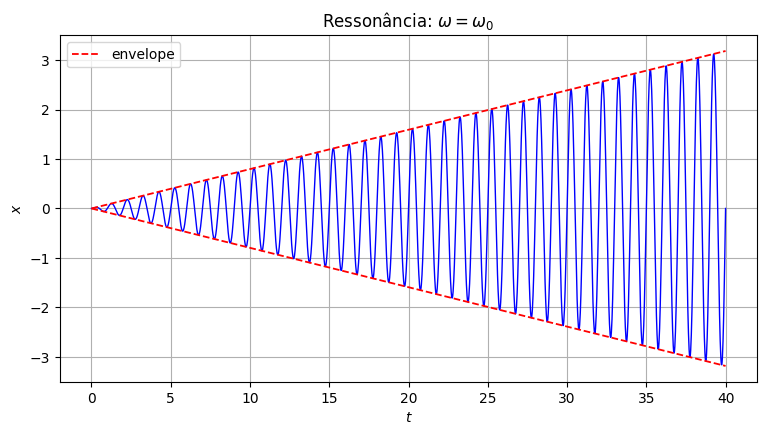

In [21]:
expr = (sp.cos(w_s*t_s) - sp.cos(w0_s*t_s)) / (w0_s**2 - w_s**2)
limite = sp.limit(expr, w_s, w0_s)
print("Limite quando ω→ω₀:", limite)
print("x_p no limite:", sp.simplify((F0_s/m_s)*limite))

t_vals = np.linspace(0, 40, 2000)
x_res = F0/(2*m_*w0) * t_vals * np.sin(w0*t_vals)

plt.figure(figsize=(9, 4.5))
plt.plot(t_vals, x_res, 'b', linewidth=1)
plt.plot(t_vals, F0*t_vals/(2*m_*w0), 'r--', linewidth=1.3, label='envelope')
plt.plot(t_vals, -F0*t_vals/(2*m_*w0), 'r--', linewidth=1.3)
plt.title(r"Ressonância: $\omega=\omega_0$")
plt.xlabel("$t$"); plt.ylabel("$x$")
plt.legend()
plt.grid(True)
plt.show()

## A curva de amplitude e a ''assíntota'' da ressonância

Voltando à fórmula geral (com amortecimento) da Parte 1:

$$
R(\omega)=\dfrac{F_0}{\sqrt{(k-m\omega^2)^2+(\gamma\omega)^2}}
$$

O que acontece com essa amplitude quando $\gamma$ fica cada vez menor? No limite $\gamma\to0$ e $\omega\to\omega_0$, o denominador vai a zero e $R\to\infty$; a 'explosão' da ressonância que acabamos de calcular é, na verdade, o caso limite de um pico de amplitude que fica cada vez mais alto e mais estreito à medida que o amortecimento diminui.

Vamos reproduzir aquele gráfico clássico que já apareceu, de relance, lá em 'Por que Equações Diferenciais':

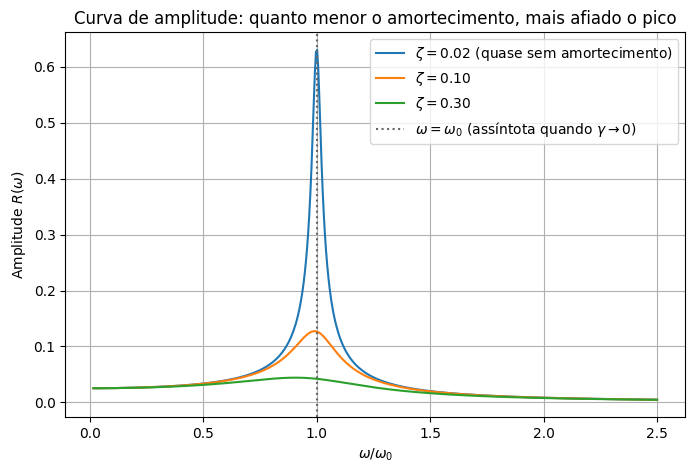

In [22]:
omega = np.linspace(0.1, 2.5*w0, 500)

plt.figure(figsize=(8, 5))
for zeta, label in [(0.02, r"$\zeta=0.02$ (quase sem amortecimento)"),
                     (0.10, r"$\zeta=0.10$"),
                     (0.30, r"$\zeta=0.30$")]:
    gam = zeta*2*np.sqrt(k_*m_)
    amp = F0/np.sqrt((k_ - m_*omega**2)**2 + (gam*omega)**2)
    plt.plot(omega/w0, amp, label=label)

plt.axvline(1, color='0.4', linestyle=':', label=r'$\omega=\omega_0$ (assíntota quando $\gamma\to0$)')
plt.xlabel(r"$\omega/\omega_0$")
plt.ylabel(r"Amplitude $R(\omega)$")
plt.title(r"Curva de amplitude: quanto menor o amortecimento, mais afiado o pico")
plt.legend()
plt.grid(True)
plt.show()

## Fechando o capítulo

Com isso, fechamos o círculo completo das EDOs lineares de segunda ordem: modelagem, homogêneas (nos três casos), a teoria geral, vibrações livres, o método dos coeficientes a determinar, e agora vibrações forçadas, com batimento e ressonância explicados de ponta a ponta, com fórmulas exatas por trás de cada gráfico que só tínhamos simulado numericamente lá no começo do capítulo.

Ainda fica pendente a **variação de parâmetros** (para quando $F(t)$ não se encaixa na tabela de coeficientes a determinar), um tema para retomar mais adiante.